# 🎭 MimicTalk + CMPE492 Hybrid Pipeline
**Run cells top-to-bottom.** After Cell 2 (big install), do **Runtime → Restart runtime**, then continue from Cell 3.

In [ ]:
# ── CELL 1: Clone repo ──
!git clone https://github.com/yerfor/MimicTalk.git
%cd MimicTalk

Cloning into 'MimicTalk'...
remote: Enumerating objects: 763, done.
remote: Counting objects: 100% (763/763), done.
remote: Compressing objects: 100% (472/472), done.
remote: Total 763 (delta 261), reused 760 (delta 258), pack-reused 0 (from 0)
Receiving objects: 100% (763/763), 23.79 MiB | 15.29 MiB/s, done.
Resolving deltas: 100% (261/261), done.
/content/MimicTalk


In [ ]:
# ── CELL 2: Install all dependencies (slow ~10 min) ──
# After this cell finishes → Runtime > Restart runtime → continue from Cell 3

import subprocess, sys

print("── [0] System libs for PyAudio ──")
!apt-get update -qq && apt-get install -y -qq libportaudio2 portaudio19-dev

print("── [1] PyTorch 2.4 (CUDA 12.1) ──")
!pip install -q torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 \
    --index-url https://download.pytorch.org/whl/cu121

print("── [2] Patch requirements.txt ──")
!sed -i 's/numba==0.56.4/numba/'                    docs/prepare_env/requirements.txt
!sed -i 's/face-alignment==1.4.1/face-alignment/'   docs/prepare_env/requirements.txt
!sed -i 's/torchmetrics==0.11.4/torchmetrics/'       docs/prepare_env/requirements.txt
!sed -i 's/scipy==1.11.1/scipy/'                     docs/prepare_env/requirements.txt
!sed -i '/httpx==0.23.3/d'                           docs/prepare_env/requirements.txt

print("── [3] pip requirements ──")
!pip install -q -r docs/prepare_env/requirements.txt

print("── [4] openmim + mmcv ──")
!pip install -q cython openmim==0.3.9
!pip install -q --upgrade setuptools requests packaging rich filelock tqdm jedi
!mim install mmcv==2.1.0

print("── [5] PyTorch3D ──")
!pip install -q "git+https://github.com/facebookresearch/pytorch3d.git@stable"

print("── [6] Extra fixes ──")
!pip install -q --upgrade librosa
!pip install transformers==4.40.0 -q
!pip install -q gdown

print("\n✅ Done. Now do: Runtime > Restart runtime, then run Cell 3 onwards.")

── [0] System libs for PyAudio ──
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
dpkg: libjack-jackd2-0:amd64: dependency problems, but removing anyway as you requested:
 libavdevice58:amd64 depends on libjack-jackd2-0 (>= 1.9.10+20150825) | libjack-0.125; however:
  Package libjack-jackd2-0:amd64 is to be removed.
  Package libjack-0.125 is not installed.
  Package libjack-jackd2-0:amd64 which provides libjack-0.125 is to be removed.
 libavdevice58:amd64 depends on libjack-jackd2-0 (>= 1.9.10+20150825) | libjack-0.125; however:
  Package libjack-jackd2-0:amd64 is to be removed.
  Package libjack-0.125 is not installed.
  Package libjack-jackd2-0:amd64 which provides libjack-0.125 is to be removed.

(Reading database ... 121852 files and directories currently installed.)
Removing libjack-jackd2-0:amd64 (1.9.20~dfsg-1) ...
Selecting previously uns

## ▶️ After Runtime Restart — Start Here

In [ ]:
# ── CELL 3: Restore working directory & env vars (run after every restart) ──
%cd MimicTalk
%env PYTHONPATH=.
%env HF_ENDPOINT=https://hf-mirror.com
print("CWD:", __import__('os').getcwd())

/content/MimicTalk
env: PYTHONPATH=.
env: HF_ENDPOINT=https://hf-mirror.com
CWD: /content/MimicTalk


## 📦 Download Pretrained Models

In [ ]:
# ── CELL 4: BFM face model ──
!gdown --folder '1o4t5YIw7w4cMUN4bgU9nPf6IyWVG1bEk'
!mkdir -p deep_3drecon/BFM
!mv BFM/* deep_3drecon/BFM/ && rmdir BFM
!echo "BFM files:" && ls deep_3drecon/BFM/

Retrieving folder contents
Processing file 1SPM3IHsyNAaVMwqZZGV6QVaV7I2Hly0v 01_MorphableModel.mat
Processing file 1MSldX9UChKEb3AXLVTPzZQcsbGD4VmGF BFM_exp_idx.mat
Processing file 180ciTvm16peWrcpl4DOekT9eUQ-lJfMU BFM_front_idx.mat
Processing file 1KX9MyGueFB3M-X0Ss152x_johyTXHTfU BFM_model_front.mat
Processing file 19-NyZn_I0_mkF-F5GPyFMwQJ_-WecZIL Exp_Pca.bin
Processing file 11ouQ7Wr2I-JKStp2Fd1afedmWeuifhof facemodel_info.mat
Processing file 18ICIvQoKX-7feYWP61RbpppzDuYTptCq index_mp468_from_mesh35709.npy
Processing file 1VktuY46m0v_n_d4nvOupauJkK4LF6mHE std_exp.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1SPM3IHsyNAaVMwqZZGV6QVaV7I2Hly0v
From (redirected): https://drive.google.com/uc?id=1SPM3IHsyNAaVMwqZZGV6QVaV7I2Hly0v&confirm=t&uuid=ebf6e064-4820-4542-b981-43e986b81648
To: /content/MimicTalk/BFM/01_MorphableModel.mat
100% 241M/241M [00:05<00:00, 43.9MB/

In [ ]:
# ── CELL 5: MimicTalk pretrained checkpoints ──
!gdown --folder '1Kc6ueDO9HFDN3BhtJCEKNCZtyKHSktaA'
!mkdir -p checkpoints checkpoints_mimictalk
!cp -r MimicTalk/checkpoints/*          checkpoints/
!cp -r MimicTalk/checkpoints_mimictalk/* checkpoints_mimictalk/
!rm -rf MimicTalk
print("checkpoints/")
!ls checkpoints/
print("checkpoints_mimictalk/")
!ls checkpoints_mimictalk/

Retrieving folder contents
Retrieving folder 118AW8ooS-N0C8jZ8jz3tMTezjg8yElvH checkpoints
Retrieving folder 1TlvcQD5MFAiR-mculytzrvxeuyOpau7c 240112_icl_audio2secc_vox2_cmlr
Processing file 1ly81mojEwTEuK7__dG-MkAkwZZRrsNqK config.yaml
Processing file 18-JMK7K-lBIOp5BL2_bCbgOWvGSxuVYd model_ckpt_steps_1856000.ckpt
Retrieving folder 1kiGgzTD1csPynfzmofh_whzHpgJe8n1F mimictalk_orig
Retrieving folder 1KM0GubbN0B6l3CCAL31341TYaFmJCXAx os_secc2plane_torso
Processing file 14x7WCI3iwrpL2Wrs2xLokLE50iIpGAqF config.yaml
Processing file 1kfz0Wg3Kv9YmfrNnQKIqd6qPRDVAfiQZ model_ckpt_steps_100000.ckpt
Retrieving folder 1uOUP2P-minqW4Etq_cE7MiRVReTXniUy pretrained_ckpts
Processing file 1qlg75zNjyESUtfJVn1ne3sEHQLF6eh-1 mit_b0.pth
Retrieving folder 1zTGwpYO73iuIE_jaDGtwAn_IUYW6UeHP checkpoints_mimictalk
Retrieving folder 1JIdbABpHI_iPXVk84hA94Os33-kjiums German_20s
Processing file 1TTdyysOMwCLObapZC-5zkwdpI6kNQ_F1 config.yaml
Processing file 1QhA9pI0r4vGf_1ZInHGiqAxdCCXSMFM- model_ckpt_steps_10000.c

## 🛠️ Apply Hotfixes
*These patch upstream bugs in MimicTalk source. Run once per session.*

In [ ]:
# ── CELL 6: Apply all hotfixes ──
from pathlib import Path

# Fix 1: VisibleDeprecationWarning import crash
print("Fix 1: preprocess.py VisibleDeprecationWarning")
!sed -i "12s/.*VisibleDeprecationWarning.*/# &/" deep_3drecon/util/preprocess.py

# Fix 2+3: numpy.quantile import (image + video)
for path in [
    "data_gen/utils/process_image/fit_3dmm_landmark.py",
    "data_gen/utils/process_video/fit_3dmm_landmark.py",
]:
    print(f"Fix 2/3: {path}")
    !sed -i 's/^from numpy\.lib\.function_base import quantile$/from numpy import quantile/' "{path}" || true

# Fix 4: scatter_np shape unpack crash in mp_segmenter.py
print("Fix 4: scatter_np in mp_segmenter.py")
mp_path = Path("data_gen/utils/mp_feature_extractors/mp_segmenter.py")
assert mp_path.exists(), f"Not found: {mp_path}"

new_fn = r'''
def scatter_np(condition_img, classSeg=6):
    import numpy as np
    x = np.asarray(condition_img)
    if x.ndim == 2:
        x = x[None, None, :, :]
    elif x.ndim == 3:
        c = x.shape[-1]
        x = np.argmax(x, axis=-1) if c > 4 else x[..., 0]
        x = x[None, None, :, :]
    elif x.ndim == 4:
        if x.shape[1] != 1 and x.shape[-1] >= 1:
            c = x.shape[-1]
            x = np.argmax(x, axis=-1) if c > 4 else x[..., 0]
            x = x[:, None, :, :]
    elif x.ndim == 5:
        c = x.shape[-1]
        x = np.argmax(x, axis=-1) if c > 4 else x[..., 0]
    else:
        raise ValueError(f"scatter_np: unexpected shape {x.shape}")
    x = np.clip(x.astype(np.int64), 0, classSeg - 1)
    out = np.eye(classSeg, dtype=np.float32)[x[:, 0, :, :]]
    return out.transpose(0, 3, 1, 2)
'''

text  = mp_path.read_text()
lines = text.splitlines(True)
start = next(i for i, l in enumerate(lines) if l.startswith("def scatter_np"))
end   = next((j for j in range(start + 1, len(lines)) if lines[j].startswith("def ")), len(lines))
mp_path.write_text("".join(lines[:start]) + new_fn + "\n" + "".join(lines[end:]))

print("✅ All hotfixes applied.")


Fix 1: preprocess.py VisibleDeprecationWarning
Fix 2/3: data_gen/utils/process_image/fit_3dmm_landmark.py
Fix 2/3: data_gen/utils/process_video/fit_3dmm_landmark.py
Fix 4: scatter_np in mp_segmenter.py
✅ All hotfixes applied.


## 🎬 Upload & Preprocess Source Video

In [ ]:
# ── CELL 7: Upload source video ──
from google.colab import files
import os

target_dir = "data/raw/uploads"
os.makedirs(target_dir, exist_ok=True)

print("Upload ONE source video (.mp4). Aim for a clean frontal face, 15-30 sec.")
uploaded = files.upload()

video_path = video_id = None
if uploaded:
    filename = list(uploaded.keys())[0]
    video_path = os.path.join(target_dir, filename)
    os.rename(filename, video_path)
    video_id = os.path.splitext(filename)[0]
    print(f"✅ Saved → {video_path}  |  video_id = {video_id}")
else:
    print("No file uploaded.")

Upload ONE source video (.mp4). Aim for a clean frontal face, 15-30 sec.


Saving myTrainingShorted_clip_zoomed_shifted.mp4 to myTrainingShorted_clip_zoomed_shifted.mp4
✅ Saved → data/raw/uploads/myTrainingShorted_clip_zoomed_shifted.mp4  |  video_id = myTrainingShorted_clip_zoomed_shifted


In [ ]:
# ── CELL 8: (Optional) Trim & square-resize video ──
# Adjust start_time / duration as needed; skip this cell to use the raw upload.
import os

if 'video_path' in vars() and video_path and os.path.exists(video_path):
    start_time = "00:00:00"
    duration   = "20"   # seconds
    fps        = 25

    out_id   = f"{video_id}_proc"
    out_path = os.path.join(os.path.dirname(video_path), f"{out_id}.mp4")

    vf  = f"fps={fps},scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2"
    cmd = f'ffmpeg -y -ss {start_time} -i "{video_path}" -t {duration} -vf "{vf}" "{out_path}"'
    !bash -lc "$cmd"

    video_path = out_path
    video_id   = out_id
    print("Updated video_path:", video_path)
else:
    print("Skipped — no video_path set.")

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `bash -lc "ffmpeg -y -ss 00:00:00 -i "data/raw/uploads/myTrainingShorted_clip_zoomed_shifted.mp4" -t 20 -vf "fps=25,scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2" "data/raw/uploads/myTrainingShorted_clip_zoomed_shifted_proc.mp4""'
Updated video_path: data/raw/uploads/myTrainingShorted_clip_zoomed_shifted_proc.mp4


## 🏋️ Train MimicTalk on Your Video

In [ ]:
# ── STEP 1: Diagnose exact versions ──
import torch, sys
print("Python  :", sys.version)
print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)

# ── STEP 2: Try available wheel URLs in order ──
import subprocess

URLS = [
    # Exact torch version strings OpenMMLab uses
    "https://download.openmmlab.com/mmcv/dist/cu121/torch2.4.0/index.html",
    "https://download.openmmlab.com/mmcv/dist/cu121/torch2.3/index.html",
    "https://download.openmmlab.com/mmcv/dist/cu118/torch2.4.0/index.html",
    # Newer mmcv version which has py3.12 wheels
    "https://download.openmmlab.com/mmcv/dist/cu121/torch2.4.0/index.html",
]

# First just list what's available for our combo
!pip index versions mmcv \
    -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.4.0/index.html \
    2>/dev/null | head -5

!pip index versions mmcv \
    -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.4/index.html \
    2>/dev/null | head -5

Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch : 2.4.0+cu121
CUDA    : 12.1
mmcv (2.2.0)
Available versions: 2.2.0, 2.1.0, 2.0.1, 2.0.0, 1.7.2, 1.7.1, 1.7.0, 1.6.2, 1.6.1, 1.6.0, 1.5.3, 1.5.2, 1.5.1, 1.5.0, 1.4.8, 1.4.7, 1.4.6, 1.4.5, 1.4.4, 1.4.3, 1.4.2, 1.4.1, 1.4.0, 1.3.18, 1.3.17, 1.3.16, 1.3.15, 1.3.14, 1.3.13, 1.3.12, 1.3.11, 1.3.10, 1.3.9, 1.3.8, 1.3.7, 1.3.6, 1.3.5, 1.3.4, 1.3.3, 1.3.1, 1.3.0, 1.2.7, 1.2.6, 1.2.5, 1.2.4, 1.2.3, 1.2.2, 1.2.1, 1.2.0, 1.1.6, 1.1.5, 1.1.4, 1.1.3, 1.1.2, 1.1.1, 1.1.0, 1.0.5, 1.0.4, 1.0.3, 1.0.2, 1.0.1, 1.0.0, 0.6.2, 0.6.1, 0.6.0, 0.5.9, 0.5.8, 0.5.7, 0.5.6, 0.5.5, 0.5.4, 0.5.3, 0.5.1, 0.5.0, 0.4.4, 0.4.3, 0.4.2, 0.4.0, 0.3.2, 0.3.1, 0.3.0, 0.2.16, 0.2.15, 0.2.14, 0.2.13, 0.2.12, 0.2.11, 0.2.10, 0.2.9, 0.2.8, 0.2.7, 0.2.6, 0.2.5, 0.2.4, 0.2.3, 0.2.2, 0.2.1, 0.2.0
mmcv (2.2.0)
Available versions: 2.2.0, 2.1.0, 2.0.1, 2.0.0, 1.7.2, 1.7.1, 1.7.0, 1.6.2, 1.6.1, 1.6.0, 1.5.3, 1.5.2, 1.5.1, 1.5.0, 1.4.8, 1.4.7, 1.4.6, 1.4.5, 1.4.4, 1.

In [ ]:
!pip install mmcv==2.2.0 \
    -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.4.0/index.html \
    --no-build-isolation -q

import importlib, sys
importlib.invalidate_caches()
for k in [k for k in sys.modules if 'mmcv' in k]:
    del sys.modules[k]

try:
    import mmcv
    from mmcv.cnn import ConvModule
    print("mmcv", mmcv.__version__, "ready to train.")
except Exception as e:
    print("FAILED:", e)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.7/452.7 kB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 31.1 MB/s eta 0:00:00
mmcv 2.2.0 ready to train.


/usr/local/lib/python3.12/dist-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \


In [ ]:
# ── Fix: overwrite the broken system setuptools in-place ──
!pip install setuptools --upgrade \
    --target /usr/local/lib/python3.12/dist-packages/ \
    --ignore-installed -q

# Verify the broken line is gone
!python -c "import pkg_resources; print('pkg_resources OK')"
!python -c "import triton; print('triton OK')"
!python -c "import torchvision; print('torchvision OK')"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openxlab 0.1.3 requires filelock~=3.14.0, but you have filelock 3.25.0 which is incompatible.
openxlab 0.1.3 requires packaging~=24.0, but you have packaging 26.0 which is incompatible.
openxlab 0.1.3 requires requests~=2.28.2, but you have requests 2.32.5 which is incompatible.
openxlab 0.1.3 requires rich~=13.4.2, but you have rich 14.3.3 which is incompatible.
openxlab 0.1.3 requires setuptools~=60.2.0, but you have setuptools 82.0.0 which is incompatible.
openxlab 0.1.3 requires tqdm~=4.65.0, but you have tqdm 4.67.3 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
bigframes 2.36.0 requires rich<14,>=12.4.4, but you have rich 14.3.3 which is incompatible.
Traceback (most recent call last):
  File "<string>", line 1,

In [ ]:
# ── Patch broken pkg_resources in-place (affects all subprocesses) ──
!sed -i \
  's/register_finder(pkgutil.ImpImporter, find_on_path)/pass  # patched: ImpImporter removed in py3.12/' \
  /usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py

# Confirm the patch is in the file
!grep "patched" /usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py

# Confirm subprocess sees it fixed now
!python -c "import torchvision; from mmcv.cnn import ConvModule; print('All OK — safe to train')"

sed: can't read /usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py: No such file or directory
grep: /usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py: No such file or directory
/usr/local/lib/python3.12/dist-packages/mmengine/optim/optimizer/zero_optimizer.py:11: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import \
All OK — safe to train


In [ ]:
# ── CELL 9: Personalize MimicTalk (~20-30 min on T4) ──
import time, os, glob

def _resolve_video():
    global video_path, video_id
    if 'video_path' in globals() and video_path and os.path.exists(video_path):
        return video_path, video_id
    candidates = sorted(
        glob.glob("data/raw/uploads/*.mp4") + glob.glob("data/raw/uploads/*.mov"),
        key=os.path.getmtime)
    if not candidates:
        return None, None
    video_path = candidates[-1]
    video_id   = os.path.splitext(os.path.basename(video_path))[0]
    print("[auto] video_path:", video_path)
    return video_path, video_id

video_path, video_id = _resolve_video()
if not video_path:
    print("❌ No source video found. Run Cell 7 first.")
else:
    work_dir = f"checkpoints_mimictalk/{video_id}"
    os.makedirs(work_dir, exist_ok=True)
    print(f"Training on: {video_path}")
    print(f"Saving to:   {work_dir}")

    t0 = time.time()
    !python inference/train_mimictalk_on_a_video.py \
        --video_id  "{video_path}" \
        --max_updates 2000 \
        --work_dir  "{work_dir}"
    mimictalk_train_sec = time.time() - t0
    print(f"\n⏱ Training time: {mimictalk_train_sec/60:.1f} min")

    ckpts = sorted(glob.glob(f"{work_dir}/*.ckpt"), key=os.path.getmtime)
    torso_ckpt_path = ckpts[-1] if ckpts else None
    cfg_path = os.path.join(work_dir, "config.yaml")
    print("[ckpt]", torso_ckpt_path or "NOT FOUND")
    print("[cfg] ", "✅" if os.path.exists(cfg_path) else "❌ MISSING", cfg_path)

[auto] video_path: data/raw/uploads/myTrainingShorted_clip_zoomed_shifted.mp4
Training on: data/raw/uploads/myTrainingShorted_clip_zoomed_shifted.mp4
Saving to:   checkpoints_mimictalk/myTrainingShorted_clip_zoomed_shifted
/content/MimicTalk/utils/commons/ckpt_utils.py:26: SyntaxWarning: invalid escape sequence '\_'
  key=lambda x: -int(re.findall('.*steps\_(\d+)\.ckpt', x)[0]))
2026-03-04 11:35:33.293794: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772624133.315275    7077 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772624133.321759    7077 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772624133.338355    7077 computation_place

## 🎵 Upload Driving Audio & Run Inference

In [ ]:
# ── CELL 10: Upload driving audio (or auto-extract from source video) ──
from google.colab import files
import os

target_dir = "data/raw/examples"
os.makedirs(target_dir, exist_ok=True)

print("Upload a .wav driving audio (or press Cancel to extract from source video).")
uploaded = files.upload()

driving_audio_path = None
if uploaded:
    filename = list(uploaded.keys())[0]
    driving_audio_path = os.path.join(target_dir, filename)
    os.rename(filename, driving_audio_path)
    print("Saved audio →", driving_audio_path)
elif 'video_path' in vars() and video_path and os.path.exists(video_path):
    driving_audio_path = os.path.join(target_dir, f"{video_id}_audio.wav")
    !ffmpeg -y -i "{video_path}" -vn -ac 1 -ar 16000 "{driving_audio_path}" -loglevel error
    print("Extracted audio →", driving_audio_path)
else:
    print("No audio uploaded and no source video found.")

Upload a .wav driving audio (or press Cancel to extract from source video).


Saving elecanlabsVoice.mp3 to elecanlabsVoice.mp3
Saved audio → data/raw/examples/elecanlabsVoice.mp3


In [ ]:
# ── Download a natural speech sample (LJ Speech) ──
import subprocess, os

os.makedirs("data/raw/examples", exist_ok=True)

# LJ Speech sample — natural, clear, conversational pace
subprocess.run(
    "wget -q 'https://data.keithito.com/data/speech/LJSpeech-1.1/wavs/LJ001-0001.wav' "
    "-O data/raw/examples/lj_speech.wav",
    shell=True
)

driving_audio_path = "data/raw/examples/lj_speech.wav"
print("✅" if os.path.exists(driving_audio_path) else "❌", driving_audio_path)

✅ data/raw/examples/lj_speech.wav


In [ ]:
import glob
print(glob.glob("data/**/*.wav", recursive=True))
print(glob.glob("/content/**/*.wav", recursive=True))

['data/raw/examples/80_vs_60_10s.wav', 'data/raw/examples/driving_audio_16k.wav', 'data/raw/examples/lj_speech.wav', 'data/raw/examples/driving_audio_16kab07e5a6-17c0-11f1-9b18-0242ac1c000c_16k.wav']
['/content/MimicTalk/data/raw/examples/80_vs_60_10s.wav', '/content/MimicTalk/data/raw/examples/driving_audio_16k.wav', '/content/MimicTalk/data/raw/examples/lj_speech.wav', '/content/MimicTalk/data/raw/examples/driving_audio_16kab07e5a6-17c0-11f1-9b18-0242ac1c000c_16k.wav']


In [ ]:
# ── Patch system pkg_resources for Python 3.12 compatibility ──
import subprocess

paths_to_patch = [
    "/usr/lib/python3/dist-packages/pkg_resources/__init__.py",
    "/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py",
]

for path in paths_to_patch:
    result = subprocess.run(f"grep -c 'ImpImporter' {path}", shell=True, capture_output=True, text=True)
    if result.stdout.strip() != "0":
        subprocess.run(
            f"sed -i 's/register_finder(pkgutil.ImpImporter, find_on_path)/pass  # patched: ImpImporter removed in Python 3.12/' {path}",
            shell=True
        )
        print(f"✅ Patched: {path}")
    else:
        print(f"⏭ Already clean: {path}")

# Verify
import importlib, sys
for mod in ["pkg_resources", "webrtcvad"]:
    if mod in sys.modules:
        del sys.modules[mod]
try:
    import webrtcvad
    print("✅ webrtcvad imports OK")
except Exception as e:
    print("❌", e)

✅ Patched: /usr/lib/python3/dist-packages/pkg_resources/__init__.py
✅ Patched: /usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py
✅ webrtcvad imports OK


In [ ]:
# ── Force-reload pkg_resources after patch ──
import sys, pkgutil, importlib, types

# Fake ImpImporter on the live pkgutil module so cached code doesn't crash
if not hasattr(pkgutil, 'ImpImporter'):
    pkgutil.ImpImporter = type('ImpImporter', (), {})
    print("✅ Injected fake pkgutil.ImpImporter")

# Force reload both pkg_resources locations
for mod_name in list(sys.modules.keys()):
    if 'pkg_resources' in mod_name or 'webrtcvad' in mod_name:
        del sys.modules[mod_name]

import pkg_resources
import webrtcvad
print("✅ webrtcvad imports OK")

✅ webrtcvad imports OK


In [ ]:
import subprocess

path = "/usr/lib/python3/dist-packages/pkg_resources/__init__.py"

# Check how many ImpImporter references remain
result = subprocess.run(f"grep -n 'ImpImporter' {path}", shell=True, capture_output=True, text=True)
print(result.stdout)

# Patch all remaining occurrences
subprocess.run(
    f"sed -i 's/register_namespace_handler(pkgutil.ImpImporter, file_ns_handler)/pass  # patched: ImpImporter removed in Python 3.12/' {path}",
    shell=True
)

# Verify none remain
result2 = subprocess.run(f"grep -n 'ImpImporter' {path}", shell=True, capture_output=True, text=True)
remaining = result2.stdout.strip()
if remaining:
    print("⚠️ Still remaining:\n", remaining)
else:
    print("✅ All ImpImporter references patched")

2172:pass  # patched: ImpImporter removed in Python 3.12
2327:pass  # patched: ImpImporter removed in Python 3.12

⚠️ Still remaining:
 2172:pass  # patched: ImpImporter removed in Python 3.12
2327:pass  # patched: ImpImporter removed in Python 3.12


In [ ]:
import subprocess

# 1. Patch webrtcvad.py — remove the pkg_resources import (it's only used for version checking)
ret = subprocess.run(
    "sed -i 's/import pkg_resources/# import pkg_resources  # patched for Python 3.12/' "
    "/usr/local/lib/python3.12/dist-packages/webrtcvad.py",
    shell=True, capture_output=True, text=True
)
print("webrtcvad patch:", "✅" if ret.returncode == 0 else "❌ " + ret.stderr)

# 2. Verify
result = subprocess.run(
    "grep -n 'pkg_resources' /usr/local/lib/python3.12/dist-packages/webrtcvad.py",
    shell=True, capture_output=True, text=True
)
print(result.stdout or "✅ No pkg_resources references remain")

# 3. Quick import test in subprocess
test = subprocess.run("python -c \"import webrtcvad; print('webrtcvad OK')\"",
                      shell=True, capture_output=True, text=True)
print(test.stdout.strip() or test.stderr.strip())

webrtcvad patch: ✅
1:# # import pkg_resources  # patched for Python 3.12  # patched for Python 3.12

webrtcvad OK


In [ ]:
import subprocess

subprocess.run(
    "sed -i \"s/__version__ = pkg_resources.get_distribution('webrtcvad').version/__version__ = '2.0.10'  # patched for Python 3.12/\" "
    "/usr/local/lib/python3.12/dist-packages/webrtcvad.py",
    shell=True
)

test = subprocess.run("python -c \"import webrtcvad; print('webrtcvad OK, version:', webrtcvad.__version__)\"",
                      shell=True, capture_output=True, text=True)
print(test.stdout.strip() or test.stderr.strip())

webrtcvad OK, version: 2.0.10


In [ ]:
import subprocess

ret = subprocess.run(
    "pip install setuptools --upgrade "
    "--target /usr/lib/python3/dist-packages/ "
    "--ignore-installed -q",
    shell=True, capture_output=True, text=True
)
print("returncode:", ret.returncode)
print(ret.stderr[-300:] if ret.stderr else "no stderr")

# Verify
test = subprocess.run(
    "python -c \"import pkg_resources; import webrtcvad; import pygame; print('✅ all OK')\"",
    shell=True, capture_output=True, text=True
)
print(test.stdout.strip() or test.stderr[-500:])

returncode: 0
openxlab 0.1.3 requires tqdm~=4.65.0, but you have tqdm 4.67.3 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
bigframes 2.36.0 requires rich<14,>=12.4.4, but you have rich 14.3.3 which is incompatible.

pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
✅ all OK


In [ ]:
import subprocess

path = "/usr/lib/python3/dist-packages/pkg_resources/__init__.py"

# Patch the find_module call on line ~2213
subprocess.run(
    f"sed -i 's/loader = importer.find_module(packageName)/loader = None  # patched: find_module removed in Python 3.12/' {path}",
    shell=True
)

# Clear all .pyc caches for pkg_resources
subprocess.run("find /usr/lib/python3/dist-packages/pkg_resources -name '*.pyc' -delete", shell=True)
subprocess.run("find /usr/lib/python3/dist-packages/__pycache__ -name 'pkg_resources*' -delete 2>/dev/null", shell=True)

# Verify
test = subprocess.run(
    "python -c \"import pkg_resources; import webrtcvad; import pygame; print('✅ all OK')\"",
    shell=True, capture_output=True, text=True
)
print(test.stdout.strip() or test.stderr[-500:])

pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html
✅ all OK


In [ ]:
import os, subprocess

wav = "data/raw/examples/lj_speech.wav"
print(f"Size: {os.path.getsize(wav) if os.path.exists(wav) else 'NOT FOUND'} bytes")

# Re-download from a reliable mirror
os.makedirs("data/raw/examples", exist_ok=True)
subprocess.run(
    "wget -q 'https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3' "
    "-O data/raw/examples/driving.mp3",
    shell=True
)

# Convert mp3 → 16k wav directly
ret = subprocess.run(
    "ffmpeg -y -i data/raw/examples/driving.mp3 "
    "-ac 1 -ar 16000 -sample_fmt s16 -t 10 "  # -t 10 = first 10 seconds only
    "data/raw/examples/driving_audio_16k.wav",
    shell=True, capture_output=True, text=True
)
size = os.path.getsize("data/raw/examples/driving_audio_16k.wav") if os.path.exists("data/raw/examples/driving_audio_16k.wav") else 0
print(f"✅ {size//1024} KB" if size > 0 else f"❌ {ret.stderr[-200:]}")

Size: 0 bytes
✅ 312 KB


In [ ]:
import os

# Point directly to the already-converted file
driving_audio_path = "data/raw/examples/driving_audio_16k.wav"
print(f"Size: {os.path.getsize(driving_audio_path)//1024} KB")

Size: 312 KB


In [ ]:
import os, glob, subprocess, shlex

# Remove cached file to force re-conversion
if os.path.exists("data/raw/examples/driving_audio_16k.wav"):
    os.remove("data/raw/examples/driving_audio_16k.wav")
    print("🗑 Cleared old audio cache")

# Find the uploaded ElevenLabs mp3
mp3s = glob.glob("data/raw/examples/*.mp3") + glob.glob("/content/*.mp3")
print("Found mp3s:", mp3s)

if mp3s:
    driving_audio_path = mp3s[0]
    # Convert immediately
    ret = subprocess.run(
        f'ffmpeg -y -i {shlex.quote(driving_audio_path)} -ac 1 -ar 16000 -sample_fmt s16 data/raw/examples/driving_audio_16k.wav',
        shell=True, capture_output=True, text=True
    )
    size = os.path.getsize("data/raw/examples/driving_audio_16k.wav")
    print(f"✅ Converted: {driving_audio_path} → {size//1024} KB")
else:
    print("❌ No mp3 found — upload your ElevenLabs file first via Cell 10")

🗑 Cleared old audio cache
Found mp3s: ['data/raw/examples/elecanlabsVoice.mp3', 'data/raw/examples/driving.mp3']
✅ Converted: data/raw/examples/elecanlabsVoice.mp3 → 1146 KB


In [ ]:
# ── CELL 11: Run MimicTalk inference ──
import os, time, glob, subprocess, shlex

# ── Resolve checkpoint dir ──
def _find_ckpt_dir():
    for d in [
        globals().get("work_dir", ""),
        f"checkpoints_mimictalk/{globals().get('video_id','')}",
        "checkpoints_mimictalk/German_20s",
    ]:
        if d and os.path.isdir(d) and os.path.exists(os.path.join(d, "config.yaml")):
            return d
    return None

torso_ckpt_dir = _find_ckpt_dir()
if not torso_ckpt_dir:
    raise FileNotFoundError("No trained checkpoint dir found. Run Cell 9 first.")

# ── Resolve driving audio ──
audio_16k_path = "data/raw/examples/driving_audio_16k.wav"
os.makedirs("data/raw/examples", exist_ok=True)

if os.path.exists(audio_16k_path) and os.path.getsize(audio_16k_path) > 1024:
    print(f"[audio 16k] using existing  ({os.path.getsize(audio_16k_path)//1024} KB)")
else:
    if not ('driving_audio_path' in globals() and driving_audio_path and os.path.exists(driving_audio_path)):
        audio_candidates = [
            f"data/raw/examples/{globals().get('video_id', '')}_audio.wav",
            "data/raw/examples/lj_speech.wav",
            "data/raw/examples/80_vs_60_10s.wav",
            "data/raw/examples/myTrainingShorted_clip_zoomed_shifted_audio.wav",
        ]
        audio_candidates += glob.glob("data/raw/examples/*.mp3")
        driving_audio_path = next((p for p in audio_candidates if os.path.exists(p)), None)
        if not driving_audio_path:
            raise FileNotFoundError("No driving audio found. Upload a .wav/.mp3 via Cell 10.")
        print("[fallback audio]", driving_audio_path)

    ret = subprocess.run(
        f'ffmpeg -y -i {shlex.quote(driving_audio_path)} -ac 1 -ar 16000 -sample_fmt s16 {shlex.quote(audio_16k_path)}',
        shell=True, capture_output=True, text=True
    )
    if ret.returncode != 0 or not os.path.exists(audio_16k_path) or os.path.getsize(audio_16k_path) == 0:
        print("ffmpeg stderr:", ret.stderr[-300:])
        raise RuntimeError("Audio pre-conversion failed.")
    print(f"[audio 16k] converted  ({os.path.getsize(audio_16k_path)//1024} KB)")

# ── Pose = source video ──
driving_pose_path  = video_path if (video_path and os.path.exists(video_path)) else "data/raw/examples/German_20s.mp4"

# ── Style = source video, but pre-extract its audio as silence ──
# (source video is silent; MimicTalk crashes if it can't find audio — we give it silence)
driving_style_path = driving_pose_path
style_16k_path     = os.path.splitext(driving_style_path)[0] + "_16k.wav"

if not (os.path.exists(style_16k_path) and os.path.getsize(style_16k_path) > 1024):
    dur_result = subprocess.run(
        f'ffprobe -v error -show_entries format=duration -of csv=p=0 {shlex.quote(driving_style_path)}',
        shell=True, capture_output=True, text=True
    )
    dur = dur_result.stdout.strip() or "30"
    subprocess.run(
        f'ffmpeg -y -f lavfi -i anullsrc=r=16000:cl=mono -t {dur} -sample_fmt s16 {shlex.quote(style_16k_path)}',
        shell=True, capture_output=True, text=True
    )
    print(f"[style 16k] silence generated  ({os.path.getsize(style_16k_path)//1024} KB)")
else:
    print(f"[style 16k] using existing  ({os.path.getsize(style_16k_path)//1024} KB)")

os.makedirs("infer_out", exist_ok=True)
output_video_path = f"infer_out/{video_id}_mimictalk.mp4"

print("ckpt  :", torso_ckpt_dir)
print("audio :", audio_16k_path)
print("pose  :", driving_pose_path)
print("style :", driving_style_path)
print("output:", output_video_path)

t0 = time.time()
!python inference/mimictalk_infer.py \
    --torso_ckpt  "{torso_ckpt_dir}" \
    --drv_aud     "{audio_16k_path}" \
    --drv_pose    "{driving_pose_path}" \
    --drv_style   "{driving_style_path}" \
    --out_name    "{output_video_path}" \
    --out_mode    final
mimictalk_infer_sec = time.time() - t0
print(f"\n⏱ Inference time: {mimictalk_infer_sec:.1f}s")

# ── Auto-find output if path changed ──
if not os.path.exists(output_video_path):
    cands = sorted(glob.glob("infer_out/**/*.mp4", recursive=True), key=os.path.getmtime)
    if cands:
        output_video_path = cands[-1]
        print("[auto] output_video_path:", output_video_path)
    else:
        print("❌ No .mp4 found under infer_out/")
else:
    print("✅ Output:", output_video_path)

[audio 16k] using existing  (1146 KB)
[style 16k] using existing  (312 KB)
ckpt  : checkpoints_mimictalk/myTrainingShorted_clip_zoomed_shifted
audio : data/raw/examples/driving_audio_16k.wav
pose  : data/raw/uploads/myTrainingShorted_clip_zoomed_shifted.mp4
style : data/raw/uploads/myTrainingShorted_clip_zoomed_shifted.mp4
output: infer_out/myTrainingShorted_clip_zoomed_shifted_mimictalk.mp4
2026-03-04 12:20:46.335235: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772626846.356308   21502 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772626846.362763   21502 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772626846.379083   21502 comp

In [ ]:
# ── CELL 11b: Upconvert output to 30fps with frame interpolation ──
import os, subprocess, shlex

input_path = output_video_path  # from Cell 11
output_30fps_path = input_path.replace(".mp4", "_30fps.mp4")

ret = subprocess.run(
    f'ffmpeg -y -i {shlex.quote(input_path)} '
    f'-filter:v "minterpolate=fps=30:mi_mode=mci:mc_mode=aobmc:me_mode=bidir:vsbmc=1" '
    f'-c:v libx264 -crf 18 -preset fast '
    f'-c:a copy '
    f'{shlex.quote(output_30fps_path)}',
    shell=True, capture_output=True, text=True
)

if ret.returncode == 0 and os.path.exists(output_30fps_path):
    size_mb = os.path.getsize(output_30fps_path) / 1024 / 1024
    print(f"✅ {output_30fps_path}  ({size_mb:.1f} MB)")
    output_video_path = output_30fps_path  # update global for preview cell
else:
    print("❌ ffmpeg failed:")
    print(ret.stderr[-500:])

## 👁️ Preview Generated Video

In [ ]:
# ── CELL 12: Preview output video ──
from IPython.display import HTML
from base64 import b64encode
import os, glob

vid = globals().get("output_video_path", None)
if not vid or not os.path.exists(vid):
    cands = sorted(glob.glob("infer_out/**/*.mp4", recursive=True), key=os.path.getmtime)
    vid = cands[-1] if cands else None

if not vid:
    print("No generated video found. Check that inference (Cell 11) completed.")
else:
    output_video_path = vid
    print("Showing:", vid)
    data_url = "data:video/mp4;base64," + b64encode(open(vid,'rb').read()).decode()
    display(HTML(f'<video width=520 controls><source src="{data_url}" type="video/mp4"></video>'))

Showing: infer_out/myTrainingShorted_clip_zoomed_shifted_mimictalk.mp4


## 🦴 [CMPE492 Phase 1] Extract MediaPipe Landmarks
This is **Module 2 — The Bridge**. It extracts 478-point facial landmarks from the MimicTalk output video and saves them as a structured `.npy` file for AniPortrait injection.

Output shape: `(N_frames, 478, 3)` — normalised `[x, y, z]` in `[0,1]` space.

In [ ]:
# ── CELL 13: Install MediaPipe ──
!pip install -q mediapipe
print("✅ MediaPipe ready.")

✅ MediaPipe ready.


In [ ]:
import subprocess
# Check current version
import mediapipe as mp
print("mediapipe version:", mp.__version__)

# Reinstall legacy-compatible version
subprocess.run("pip install -q mediapipe==0.10.9", shell=True)
print("Done — restart kernel NOT needed, just re-run Cell 14")

mediapipe version: 0.10.32
Done — restart kernel NOT needed, just re-run Cell 14


In [ ]:
import importlib, sys

# Remove all cached mediapipe modules
for key in list(sys.modules.keys()):
    if 'mediapipe' in key:
        del sys.modules[key]

# Reimport and check
import mediapipe as mp
print("mediapipe version:", mp.__version__)
print("has solutions:", hasattr(mp, 'solutions'))

mediapipe version: 0.10.32
has solutions: False


In [ ]:
import subprocess, sys
subprocess.run(f"{sys.executable} -m pip install -q mediapipe==0.10.9 --force-reinstall", shell=True)

# Then reload
for key in list(sys.modules.keys()):
    if 'mediapipe' in key:
        del sys.modules[key]

import mediapipe as mp
print("mediapipe version:", mp.__version__)
print("has solutions:", hasattr(mp, 'solutions'))

mediapipe version: 0.10.32
has solutions: False


In [ ]:
# ── CELL 14: Extract 478-point face mesh landmarks from MimicTalk output ──
import os, json, glob, urllib.request
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

# ── 1) Locate the MimicTalk output video ──────────────────────────────────────
source_video = globals().get("output_video_path", None)
if not source_video or not os.path.exists(source_video):
    cands = sorted(glob.glob("infer_out/**/*.mp4", recursive=True), key=os.path.getmtime)
    source_video = cands[-1] if cands else None
if not source_video:
    raise FileNotFoundError("No output video found. Run Cell 11 first.")
print(f"Source video : {source_video}")

_vid_id = globals().get("video_id", os.path.splitext(os.path.basename(source_video))[0])
out_dir  = os.path.dirname(source_video)
lmk_npy  = os.path.join(out_dir, f"{_vid_id}_landmarks.npy")
lmk_json = os.path.join(out_dir, f"{_vid_id}_landmarks.json")

# ── 2) Download face landmarker model if needed ───────────────────────────────
model_path = "face_landmarker.task"
if not os.path.exists(model_path):
    print("Downloading face landmarker model...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        model_path
    )
    print(f"✅ Downloaded: {model_path}")

# ── 3) Open video ─────────────────────────────────────────────────────────────
cap = cv2.VideoCapture(source_video)
assert cap.isOpened(), f"Cannot open: {source_video}"
fps_video = cap.get(cv2.CAP_PROP_FPS) or 25.0
total     = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
W         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H         = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"Resolution   : {W}×{H}  |  FPS: {fps_video:.2f}  |  Frames: {total}")

# ── 4) Run FaceLandmarker (new Tasks API) ─────────────────────────────────────
N_LANDMARKS = 478

base_options = mp_python.BaseOptions(model_asset_path=model_path)
options = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    min_face_detection_confidence=0.4,
    min_face_presence_confidence=0.4,
    min_tracking_confidence=0.4,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)
detector = mp_vision.FaceLandmarker.create_from_options(options)

all_landmarks = []
failed_frames = []
last_valid    = None
frame_idx     = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = detector.detect(mp_img)

    if result.face_landmarks:
        lmks = result.face_landmarks[0]   # 478 NormalizedLandmark
        arr  = np.array([[lm.x, lm.y, lm.z] for lm in lmks], dtype=np.float32)
        last_valid = arr
    else:
        failed_frames.append(frame_idx)
        arr = last_valid if last_valid is not None else np.zeros((N_LANDMARKS, 3), dtype=np.float32)

    all_landmarks.append(arr)
    frame_idx += 1

cap.release()
detector.close()

# ── 5) Stack and save ─────────────────────────────────────────────────────────
landmarks_np = np.stack(all_landmarks, axis=0)
np.save(lmk_npy, landmarks_np)

meta = {
    "source_video"     : os.path.abspath(source_video),
    "fps"              : float(fps_video),
    "frame_count"      : int(frame_idx),
    "landmark_count"   : N_LANDMARKS,
    "array_shape"      : list(landmarks_np.shape),
    "dtype"            : str(landmarks_np.dtype),
    "failed_frames"    : failed_frames,
    "failed_rate"      : round(len(failed_frames) / max(1, frame_idx), 4),
    "coord_convention" : "x,y in [0,1] normalised by W,H; z relative depth",
    "note"             : "Ready for AniPortrait Lmk2Video injection (Phase 2 bridge)"
}
with open(lmk_json, "w") as f:
    json.dump(meta, f, indent=2)

print(f"\n✅ Landmarks saved!")
print(f"   .npy  : {lmk_npy}")
print(f"   .json : {lmk_json}")
print(f"   Shape : {landmarks_np.shape}  dtype={landmarks_np.dtype}")
print(f"   Failed frames: {len(failed_frames)}/{frame_idx} ({meta['failed_rate']*100:.1f}%)")
if failed_frames:
    print(f"   First failures: {failed_frames[:10]}{'...' if len(failed_frames)>10 else ''}")

landmark_npy_path  = lmk_npy
landmark_json_path = lmk_json

Source video : infer_out/myTrainingShorted_clip_zoomed_shifted_mimictalk.mp4
Resolution   : 512×512  |  FPS: 25.00  |  Frames: 916

✅ Landmarks saved!
   .npy  : infer_out/myTrainingShorted_clip_zoomed_shifted_landmarks.npy
   .json : infer_out/myTrainingShorted_clip_zoomed_shifted_landmarks.json
   Shape : (916, 478, 3)  dtype=float32
   Failed frames: 0/916 (0.0%)


Frame shape: (512, 512, 3)  |  Landmarks drawn: 478


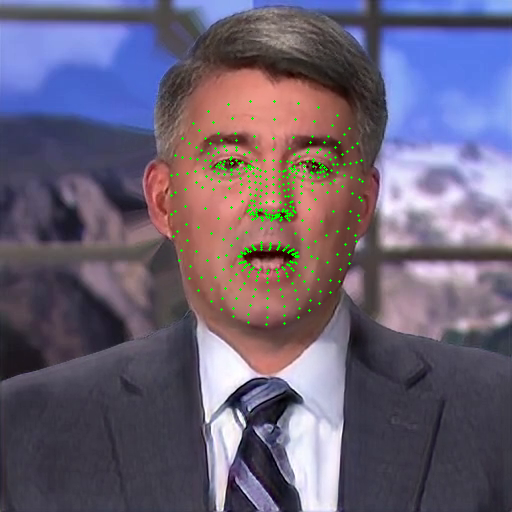

In [ ]:
# ── CELL 15: Quick sanity-check — visualise landmarks on a sample frame ──
import cv2, numpy as np
from IPython.display import display
from PIL import Image

assert 'landmark_npy_path' in globals(), "Run Cell 14 first."

lmk_data = np.load(landmark_npy_path)          # (N, 478, 3)
cap = cv2.VideoCapture(source_video)
cap.set(cv2.CAP_PROP_POS_FRAMES, len(lmk_data)//2)   # mid-point frame
ok, frame = cap.read(); cap.release()
assert ok, "Could not read sample frame."

H_f, W_f = frame.shape[:2]
vis = frame.copy()
sample_lmk = lmk_data[len(lmk_data)//2]       # (478, 3)

for pt in sample_lmk:
    px = int(pt[0] * W_f)
    py = int(pt[1] * H_f)
    cv2.circle(vis, (px, py), 1, (0, 255, 0), -1)

# show
img = Image.fromarray(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
img = img.resize((512, 512))
print(f"Frame shape: {frame.shape}  |  Landmarks drawn: {len(sample_lmk)}")
display(img)

In [ ]:
# ── CELL 16: Download landmark files ──
from google.colab import files
import os

for path in [landmark_npy_path, landmark_json_path]:
    if os.path.exists(path):
        print("Downloading:", path)
        files.download(path)
    else:
        print("Not found:", path)

Downloading: infer_out/myTrainingShorted_clip_zoomed_shifted_landmarks.npy


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: infer_out/myTrainingShorted_clip_zoomed_shifted_landmarks.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📤 Export Shared Inputs for AniPortrait

In [ ]:
# ── CELL 17: Export reference image + audio for AniPortrait notebook ──
from google.colab import files
import os, shutil

os.makedirs("shared_inputs", exist_ok=True)

# Reference image — first frame of source video
ref_img = "shared_inputs/ref_image.png"
if 'video_path' in globals() and video_path and os.path.exists(video_path):
    vf = "select=eq(n\,0),scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2"
    !ffmpeg -y -i "{video_path}" -vf "{vf}" -vframes 1 "{ref_img}" -loglevel error
    print("Reference image →", ref_img)
else:
    print("No video_path; cannot extract reference image.")

# Driving audio
aud_out = "shared_inputs/driven_audio.wav"
if 'driving_audio_path' in globals() and driving_audio_path and os.path.exists(driving_audio_path):
    shutil.copy(driving_audio_path, aud_out)
    print("Audio →", aud_out)
elif 'video_path' in globals() and video_path and os.path.exists(video_path):
    !ffmpeg -y -i "{video_path}" -vn -ac 1 -ar 16000 "{aud_out}" -loglevel error
    print("Extracted audio →", aud_out)

print("\nDownloading shared inputs...")
for p in [ref_img, aud_out]:
    if os.path.exists(p):
        files.download(p)

<>:10: SyntaxWarning: invalid escape sequence '\,'
<>:10: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_5934/2001250838.py:10: SyntaxWarning: invalid escape sequence '\,'
  vf = "select=eq(n\,0),scale=512:512:force_original_aspect_ratio=decrease,pad=512:512:(ow-iw)/2:(oh-ih)/2"


Reference image → shared_inputs/ref_image.png
Audio → shared_inputs/driven_audio.wav



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📊 Benchmarks
Run in order: Lightweight → SyncNet → ArcFace → Temporal → Efficiency → Summary

In [ ]:
# ── CELL 18: Lightweight benchmark (identity + audio-mouth correlation) ──
import os, json, csv, glob
from datetime import datetime
import cv2, numpy as np

!pip -q install opencv-python librosa soundfile facenet-pytorch >/dev/null

import librosa

def _ensure_video():
    p = globals().get("output_video_path")
    if p and os.path.exists(p): return p
    cands = sorted(glob.glob("infer_out/**/*.mp4", recursive=True), key=os.path.getmtime)
    return cands[-1] if cands else None

def _video_meta(vp):
    cap = cv2.VideoCapture(vp)
    if not cap.isOpened(): return {}
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 0)
    nf  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)  or 0)
    h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT) or 0)
    cap.release()
    return {"fps": fps, "nframes": nf, "width": w, "height": h,
            "duration_sec": nf/fps if fps else None}

def _sample_frames(vp, n=12):
    cap = cv2.VideoCapture(vp)
    nf  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    idxs = np.linspace(0, max(0, nf-1), min(n, nf)).astype(int)
    out = []
    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, f = cap.read()
        if ok: out.append(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    cap.release()
    return out

def _id_sim(ref_rgb, frames):
    if ref_rgb is None or not frames:
        return {"id_sim_mean": None, "id_error": "no_input"}
    try:
        import torch
        from facenet_pytorch import MTCNN, InceptionResnetV1
        from PIL import Image
        dev = "cuda" if torch.cuda.is_available() else "cpu"
        mtcnn  = MTCNN(image_size=160, margin=20, device=dev)
        resnet = InceptionResnetV1(pretrained="vggface2").eval().to(dev)
        def emb(rgb):
            face = mtcnn(Image.fromarray(rgb))
            if face is None: return None
            if face.ndim == 3: face = face.unsqueeze(0)
            with torch.no_grad(): return resnet(face.to(dev)).detach().cpu().numpy().flatten()
        ref_e = emb(ref_rgb)
        if ref_e is None: return {"id_sim_mean": None, "id_error": "no_ref_face"}
        sims = [float(np.dot(ref_e, e)/(np.linalg.norm(ref_e)*np.linalg.norm(e)+1e-9))
                for f in frames if (e:=emb(f)) is not None]
        return {"id_sim_mean": float(np.mean(sims)) if sims else None,
                "id_sim_std":  float(np.std(sims))  if sims else None,
                "id_error": None}
    except Exception as ex:
        return {"id_sim_mean": None, "id_error": str(ex)}

def _audio_mouth_corr(vp, ap):
    if not (ap and os.path.exists(ap) and vp and os.path.exists(vp)):
        return {"audio_mouth_corr": None}
    y, sr = librosa.load(ap, sr=16000, mono=True)
    rms = librosa.feature.rms(y=y, frame_length=2048, hop_length=512).flatten()
    rms = (rms - rms.mean()) / (rms.std() + 1e-9)
    cap = cv2.VideoCapture(vp); motion = []; prev = None
    while True:
        ok, f = cap.read()
        if not ok: break
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
        h, w = g.shape
        roi = g[int(h*.55):int(h*.95), int(w*.25):int(w*.75)]
        if prev is not None: motion.append(float(cv2.absdiff(roi, prev).mean()))
        prev = roi
    cap.release()
    if len(motion) < 10: return {"audio_mouth_corr": None}
    motion = np.array(motion); motion = (motion-motion.mean())/(motion.std()+1e-9)
    rms_r  = np.interp(np.linspace(0,1,len(motion)), np.linspace(0,1,len(rms)), rms)
    return {"audio_mouth_corr": float(np.corrcoef(rms_r, motion)[0,1])}

vp = _ensure_video()
ap = globals().get("driving_audio_path")
row = {"timestamp_utc": datetime.utcnow().isoformat(), "model": "MimicTalk",
       "video_path": vp, "audio_path": ap}
row.update(_video_meta(vp))
ref_rgb = None
src_vp = globals().get("video_path")
if src_vp and os.path.exists(src_vp):
    cap = cv2.VideoCapture(src_vp)
    ok, f0 = cap.read(); cap.release()
    if ok: ref_rgb = cv2.cvtColor(f0, cv2.COLOR_BGR2RGB)
row.update(_id_sim(ref_rgb, _sample_frames(vp)))
row.update(_audio_mouth_corr(vp, ap))
row["train_sec"] = float(globals().get("mimictalk_train_sec", float("nan")))
row["infer_sec"] = float(globals().get("mimictalk_infer_sec", float("nan")))

os.makedirs("benchmarks", exist_ok=True)
with open("benchmarks/MimicTalk_last_run.json", "w") as f: json.dump(row, f, indent=2)

csv_path = "benchmarks/summary.csv"
write_hdr = not os.path.exists(csv_path)
with open(csv_path, "a", newline="") as f:
    import csv
    w = csv.DictWriter(f, fieldnames=list(row.keys()))
    if write_hdr: w.writeheader()
    w.writerow(row)
print("Saved benchmarks/MimicTalk_last_run.json")
for k in ["fps","duration_sec","id_sim_mean","audio_mouth_corr","train_sec","infer_sec"]:
    print(f"  {k}: {row.get(k)}")

/tmp/ipykernel_5934/1559215590.py:87: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  row = {"timestamp_utc": datetime.utcnow().isoformat(), "model": "MimicTalk",


Saved benchmarks/MimicTalk_last_run.json
  fps: 25.0
  duration_sec: 36.64
  id_sim_mean: 0.9314120511213938
  audio_mouth_corr: 0.010930219795740739
  train_sec: 880.0035407543182
  infer_sec: 176.83393597602844


In [ ]:
import syncnet_python
print(dir(syncnet_python))

['SyncNetInstance', 'SyncNetModel', 'SyncNetPipeline', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'calculate_lse_metrics', 'extract_audio_from_video', 'get_version', 'safe_syncnet_inference']


In [ ]:
import syncnet_python, inspect
print(syncnet_python.__file__)
print(inspect.getsource(syncnet_python))

/usr/local/lib/python3.12/dist-packages/syncnet_python/__init__.py
"""SyncNet Python: Audio-visual synchronization detection.

This package provides a PyTorch implementation of SyncNet for detecting
synchronization between audio and video in multimedia content.
"""

__version__ = "0.2.2"

# Import main components
try:
    from .syncnet_pipeline import SyncNetPipeline
    from .SyncNetModel import S as SyncNetModel
    from .SyncNetInstance import SyncNetInstance
    from .safe_syncnet_utils import (
        safe_syncnet_inference,
        extract_audio_from_video,
        calculate_lse_metrics
    )
except ImportError:
    # Fallback for development
    SyncNetPipeline = None
    SyncNetModel = None
    SyncNetInstance = None
    safe_syncnet_inference = None
    extract_audio_from_video = None
    calculate_lse_metrics = None

__all__ = [
    "SyncNetPipeline",
    "SyncNetModel", 
    "SyncNetInstance",
    "safe_syncnet_inference",
    "extract_audio_from_video", 
    "calculate_lse

In [ ]:
from syncnet_python.syncnet_pipeline import SyncNetPipeline


ModuleNotFoundError: No module named 'scenedetect'

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "-q", "install", "scenedetect"], check=True)

from syncnet_python.syncnet_pipeline import SyncNetPipeline
print("✅ SyncNetPipeline loaded")

✅ SyncNetPipeline loaded


In [ ]:
import importlib, sys

# Clear all cached syncnet modules
for key in list(sys.modules.keys()):
    if 'syncnet' in key:
        del sys.modules[key]

# Reimport fresh
from syncnet_python.syncnet_pipeline import SyncNetPipeline
print("✅", SyncNetPipeline)

✅ <class 'syncnet_python.syncnet_pipeline.SyncNetPipeline'>


In [ ]:
# ── CELL 19: SyncNet (LSE-C / LSE-D) ──
import os, glob, json, subprocess, shlex, sys
from pathlib import Path
from datetime import datetime

MODEL_TAG = "MimicTalk"
TRIM_SEC  = 15; START_SEC = 1
EVAL_DIR  = "benchmarks/syncnet_eval"; os.makedirs(EVAL_DIR, exist_ok=True)

video_for_lse = globals().get("output_video_path") or max(
    glob.glob("infer_out/**/*.mp4", recursive=True), key=os.path.getmtime, default=None)
assert video_for_lse and os.path.exists(video_for_lse), "No output MP4 found."

def has_audio(p):
    out = subprocess.check_output(
        ["bash","-lc",f'ffprobe -v error -select_streams a -show_entries stream=codec_type -of csv=p=0 {shlex.quote(p)}'],
        text=True).strip()
    return len(out) > 0

def get_fps(p):
    out = subprocess.check_output(
        ["bash","-lc",f'ffprobe -v error -select_streams v:0 -show_entries stream=r_frame_rate -of default=nw=1:nk=1 {shlex.quote(p)}'],
        text=True).strip()
    a,b = (out+"/1").split("/")[:2]; return float(a)/float(b)

fps = get_fps(video_for_lse)
need_ext = not has_audio(video_for_lse)
drv_audio = globals().get("audio_16k_path") or globals().get("driving_audio_path")
if need_ext and (not drv_audio or not os.path.exists(drv_audio)):
    raise FileNotFoundError("Video has no audio and no driving audio path found.")

stem = Path(video_for_lse).stem
eval_video_path = f"{EVAL_DIR}/{stem}_syncnet_eval.mp4"
ff = ["ffmpeg","-y","-ss",str(START_SEC),"-i",video_for_lse]
if need_ext: ff += ["-i",drv_audio,"-map","0:v:0","-map","1:a:0"]
else: ff += ["-map","0:v:0","-map","0:a:0"]
if TRIM_SEC: ff += ["-t",str(TRIM_SEC)]
ff += ["-c:v","libx264","-pix_fmt","yuv420p","-c:a","aac","-ac","1","-ar","16000",
       "-shortest","-movflags","+faststart",eval_video_path]
subprocess.run(ff, check=True)

# ── Install syncnet-python if needed ──
try:
    from syncnet_python import SyncNetPipeline
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "--no-deps", "syncnet-python"], check=True)
    from syncnet_python import SyncNetPipeline

import torch
dev = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("weights", exist_ok=True)
if not os.path.exists("weights/syncnet_v2.model"):
    subprocess.run(["wget","-q","-O","weights/syncnet_v2.model",
                    "https://www.robots.ox.ac.uk/~vgg/software/lipsync/data/syncnet_v2.model"], check=True)
if not os.path.exists("weights/sfd_face.pth"):
    subprocess.run(["wget","-q","-O","weights/sfd_face.pth",
                    "https://www.robots.ox.ac.uk/~vgg/software/lipsync/data/sfd_face.pth"], check=True)

pipe = SyncNetPipeline(s3fd_weights="weights/sfd_face.pth",
                       syncnet_weights="weights/syncnet_v2.model", device=dev)
offset_list, conf_list, dist_list, best_conf, best_dist, _, success = pipe.inference(
    video_path=eval_video_path, audio_path=None)
assert success and conf_list, "SyncNet failed — try a clearer face / longer clip."

lse = {"timestamp_utc": datetime.utcnow().isoformat(), "model": MODEL_TAG,
       "fps": float(fps),
       "lse_c_mean": float(sum(conf_list)/len(conf_list)),
       "lse_d_mean": float(sum(dist_list)/len(dist_list)),
       "av_offset_mean_frames": float(sum(offset_list)/len(offset_list)),
       "best_conf": float(best_conf), "best_min_dist": float(best_dist),
       "base_video_path": os.path.abspath(video_for_lse),
       "eval_video_path": os.path.abspath(eval_video_path)}
print(json.dumps(lse, indent=2))
with open("benchmarks/SyncNet_LSE_last_run.json","w") as f:
    json.dump(lse, f, indent=2)
print("Saved: benchmarks/SyncNet_LSE_last_run.json")

  net.load_state_dict(torch.load(path, map_location=self.device))

  model.load_state_dict(torch.load(path, map_location=self.device))

ERROR:pyscenedetect:VideoManager is deprecated and will be removed.
INFO:pyscenedetect:Loaded 1 video, framerate: 25.000 FPS, resolution: 512 x 512
INFO:pyscenedetect:Detecting scenes...
ERROR:pyscenedetect:`base_timecode` argument is deprecated and has no effect.
  lse = {"timestamp_utc": datetime.utcnow().isoformat(), "model": MODEL_TAG,



Compute time 1.104 sec.
Framewise conf: 
[ 1.099  1.458  1.853  1.853  1.853  1.458  1.099  1.099  1.099  1.853
  1.853  1.549  1.549  1.691  3.942  4.297  4.741  4.760  6.917  6.917
  6.917  6.917  6.917  7.908  7.908  7.908  7.908  6.518  7.963  7.963
  7.963  8.290  8.290  7.031  6.381  6.215  6.215  4.898  4.898  4.782
  4.782  4.782  4.898  6.705  7.214  7.214  7.214  7.214  7.315  7.214
  6.789  6.399  6.163  5.317  4.484  4.484  4.484  4.484  4.484  4.484
  4.484  4.484  4.484  2.998  2.998  2.998  2.998  2.998  4.432  4.432
  5.238  5.250  5.501  6.035  6.721  6.802  6.802  6.802  6.827  6.827
  6.882  6.882  6.882  6.882  7.031  7.280  7.280  7.280  7.280  7.280
  6.385  4.040  2.883  2.883  2.883  2.883  2.883  4.570  6.395  6.649
  8.054  8.054  6.649  6.395  5.919  4.570  4.548  1.698  1.696  0.552
  0.065  0.065 -0.168  0.065  0.552  0.688  0.688  0.688  0.688  0.688
  0.688  1.046  1.046  1.346  1.553  1.553  1.553  1.553  2.266  3.501
  3.501  3.501  3.501  6.669  6.669 

In [ ]:
# ── CELL 20: ArcFace CSIM ──
import os, glob, json, warnings, sys, subprocess
import numpy as np, cv2
from datetime import datetime
warnings.filterwarnings("ignore")

video_for_id = (globals().get("lse") or {}).get("eval_video_path") or globals().get("output_video_path")
if not video_for_id or not os.path.exists(video_for_id):
    video_for_id = max(glob.glob("infer_out/**/*.mp4", recursive=True), key=os.path.getmtime)

# ── Install insightface if needed ──
try:
    from insightface.app import FaceAnalysis
    import onnxruntime as ort
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "insightface", "onnxruntime"], check=True)
    from insightface.app import FaceAnalysis
    import onnxruntime as ort

prov = ["CUDAExecutionProvider", "CPUExecutionProvider"] if "CUDAExecutionProvider" in ort.get_available_providers() else ["CPUExecutionProvider"]
app = FaceAnalysis(name="buffalo_l", providers=prov)
app.prepare(ctx_id=0 if "CUDA" in prov[0] else -1, det_size=(640, 640))

def biggest(faces):
    return max(faces, key=lambda f: (f.bbox[2]-f.bbox[0])*(f.bbox[3]-f.bbox[1])) if faces else None

# ── Auto reference image from source video ──
ref_vp = globals().get("video_path")
ref_image_path = "benchmarks/ref_auto.png"; os.makedirs("benchmarks", exist_ok=True)
if not (ref_vp and os.path.exists(ref_vp)):
    raise FileNotFoundError("Set video_path to your source video.")

cap = cv2.VideoCapture(ref_vp)
dur = cap.get(cv2.CAP_PROP_FRAME_COUNT) / (cap.get(cv2.CAP_PROP_FPS) + 1e-8)
for t in [0.5, 1.0, 2.0, max(0.5, dur/2)]:
    cap.set(cv2.CAP_PROP_POS_MSEC, t*1000)
    ok, f = cap.read()
    if ok and biggest(app.get(f)) is not None:
        cv2.imwrite(ref_image_path, f)
        break
cap.release()

ref_bgr = cv2.imread(ref_image_path)
ref_emb = biggest(app.get(ref_bgr)).embedding.astype(np.float32)
ref_emb /= np.linalg.norm(ref_emb) + 1e-8

# ── Compute CSIM across frames ──
cap = cv2.VideoCapture(video_for_id)
fps = cap.get(cv2.CAP_PROP_FPS) or 25
step = max(1, int(fps))
sims = []; fi = 0
while True:
    ok, f = cap.read()
    if not ok: break
    if fi % step == 0:
        face = biggest(app.get(f))
        if face:
            e = face.embedding.astype(np.float32)
            e /= np.linalg.norm(e) + 1e-8
            sims.append(float(np.dot(ref_emb, e)))
    fi += 1
    if len(sims) >= 25: break
cap.release()
assert sims, "No faces detected in eval video."

arc = {
    "timestamp_utc"      : datetime.utcnow().isoformat(),
    "eval_video"         : os.path.abspath(video_for_id),
    "ref_image"          : os.path.abspath(ref_image_path),
    "n_frames"           : len(sims),
    "arcface_csim_mean"  : float(np.mean(sims)),
    "arcface_csim_median": float(np.median(sims)),
    "arcface_csim_min"   : float(np.min(sims)),
}
print(json.dumps(arc, indent=2))
with open("benchmarks/ArcFace_last_run.json", "w") as f:
    json.dump(arc, f, indent=2)
print("Saved: benchmarks/ArcFace_last_run.json")


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 113794.01KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
{
  "timesta

In [ ]:
# ── CELL 21: Summary table ──
import json, glob, os

def load_latest(pat):
    fs = sorted(glob.glob(pat), key=os.path.getmtime)
    return json.load(open(fs[-1])) if fs else {}

sync = load_latest("benchmarks/SyncNet_LSE_last_run.json")
arc  = load_latest("benchmarks/ArcFace_last_run.json")

print(f"{'Metric':<30} {'Value':>12}")
print("-"*44)
if sync:
    print(f"{'LSE-C (↑ better)':<30} {sync.get('lse_c_mean', 'N/A'):>12.3f}")
    print(f"{'LSE-D (↓ better)':<30} {sync.get('lse_d_mean', 'N/A'):>12.3f}")
    print(f"{'AV offset (frames)':<30} {sync.get('av_offset_mean_frames','N/A'):>12.2f}")
if arc:
    print(f"{'ArcFace CSIM mean (↑)':<30} {arc.get('arcface_csim_mean','N/A'):>12.3f}")
    print(f"{'ArcFace CSIM median':<30} {arc.get('arcface_csim_median','N/A'):>12.3f}")

Metric                                Value
--------------------------------------------
LSE-C (↑ better)                      4.514
LSE-D (↓ better)                     10.446
AV offset (frames)                     1.00
ArcFace CSIM mean (↑)                 0.834
ArcFace CSIM median                   0.830


## 💾 Download All Results

In [ ]:
# ── CELL 22: Zip & download results ──
!zip -r benchmarks.zip benchmarks
from google.colab import files
files.download("benchmarks.zip")

  adding: benchmarks/ (stored 0%)
  adding: benchmarks/SyncNet_LSE_last_run.json (deflated 48%)
  adding: benchmarks/summary.csv (deflated 61%)
  adding: benchmarks/MimicTalk_last_run.json (deflated 38%)
  adding: benchmarks/syncnet_eval/ (stored 0%)
  adding: benchmarks/syncnet_eval/myTrainingShorted_clip_zoomed_shifted_mimictalk_syncnet_eval.mp4 (deflated 1%)
  adding: benchmarks/ref_auto.png (deflated 7%)
  adding: benchmarks/ArcFace_last_run.json (deflated 39%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>